<a href="https://colab.research.google.com/github/ninobronw/BPALM-TOOL-IMPLEMENTATION/blob/main/HelmNet_JLA_v2_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 10.3 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [4]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

# List contents of MyDrive to find the correct folder name
print("Contents of /content/drive/MyDrive:")
print(os.listdir('/content/drive/MyDrive'))

# Correcting the path to include the trailing space based on os.listdir output
dataset_folder_path = '/content/drive/MyDrive/IHelmet Project '

try:
    print(f"\nListing contents of: {dataset_folder_path}")
    print(os.listdir(dataset_folder_path))
except FileNotFoundError:
    print(f"Error: The folder '{dataset_folder_path}' was not found. Please double-check the path in your Google Drive.")

Contents of /content/drive/MyDrive:
['QR Linked.png', 'Untitled Diagram (1).html', 'Untitled Diagram.html', 'convertio.co', 'Document2.docx', 'Invitation à notre fête.gform', 'Comores 2019', 'SandBox', 'SCAN0013.PDF', 'SCAN0013.PDF.gdoc', 'Code électoral FCC.docx', 'Copie traduite de Index for TB Tools_Nigeria.gdoc', 'Document sans titre (189).gdoc', 'E books ', 'EBOOK Elaine N Aron - Ces gens qui ont peur d avoir peur.pdf', 'EBOOK Sebastien Fedeli - Aux voleurs.pdf', 'EBOOK Srdja Popovic Comment faire tomber un dictateur quand on est seul tout petit et sans armes -.pdf', 'Chase,James Hadley - Qui vivra, rira.pdf', 'SAS 188 - Rouge dragon T1 Gerard de Villiers.pdf', 'SAS 184 - Renegade T2 Gerard de Villiers.pdf', 'SAS 183 - Renegade T1 Gerard de Villiers.pdf', 'SAS 189 - Rouge dragon T2 Gerard de Villiers.pdf', 'SAS 185 - Feroce Guinee Gerard de Villiers.pdf', 'guide revue.pdf', '2020-02-25_083854.pdf', 'Dr ABENA refering Isidore Noris.docx', 'listes des concubines des hommes de mé

Now that we have confirmed the contents of the dataset folder, let's load the `labels.csv` file into a pandas DataFrame. This file likely contains the classification labels for your images.

In [7]:
import pandas as pd
import os

# The dataset_folder_path is defined in a previous cell and corrected to point to the Google Drive folder.
# We will use this to construct the correct path to labels.csv.
# Based on kernel state, dataset_folder_path is '/content/drive/MyDrive/IHelmet Project '

# Construct the full path to labels.csv within the dataset folder
labels_file_path = os.path.join(dataset_folder_path, 'labels.csv')

# Load the labels.csv file
try:
    labels_df = pd.read_csv(labels_file_path)
    print("Labels DataFrame loaded successfully. Here's a preview:")
    print(labels_df.head())
    print(f"\nShape of labels_df: {labels_df.shape}")
except FileNotFoundError:
    print(f"Error: labels.csv not found at {labels_file_path}. Please ensure the file is in the specified folder and the path is correct.")
except Exception as e:
    print(f"An error occurred while loading labels.csv: {e}")

Labels DataFrame loaded successfully. Here's a preview:
   label
0      0
1      0
2      0
3      0
4      0

Shape of labels_df: (4125, 1)


Before proceeding, let's examine the distribution of classes in our `labels_df` to check for any class imbalance. This is important as imbalanced datasets can lead to models that perform well on the majority class but poorly on the minority class.

# **Exploratory Data Analysis**

*texte en italique*###Plot random images from each of the classes and print their corresponding labels.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

def plot_random_images(X, y, num_images=5, title_prefix=""):
    """
    Plots a specified number of random images from a dataset (X) along with their labels (y).

    Args:
        X (numpy.ndarray): The array containing image data.
        y (pandas.Series or numpy.ndarray): The labels corresponding to the images.
        num_images (int): The number of random images to plot.
        title_prefix (str): Prefix for the plot title (e.g., 'With Helmet').
    """
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        index = random.randint(0, len(X) - 1)
        image = X[index]
        # Ensure y is treated as a Series for .iloc, or directly index if it's a numpy array
        label = y.iloc[index] if isinstance(y, pd.Series) else y[index]

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f"{title_prefix} Label: {label} ({'With Helmet' if label == 1 else 'Without Helmet'})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# At this point, 'images' and 'labels_df' are expected to be available from previous cells
# (especially the newly generated cell ensuring 'images' is loaded after re-extraction).

if 'images' in globals() and images is not None and 'labels_df' in globals() and labels_df is not None:
    print("Images and labels_df are available. Proceeding with plotting.")

    # Filter images and labels for 'With Helmet' (label=1)
    with_helmet_indices = labels_df[labels_df['label'] == 1].index
    X_with_helmet = images[with_helmet_indices]
    y_with_helmet = labels_df.loc[with_helmet_indices, 'label']

    # Filter images and labels for 'Without Helmet' (label=0)
    without_helmet_indices = labels_df[labels_df['label'] == 0].index
    X_without_helmet = images[without_helmet_indices]
    y_without_helmet = labels_df.loc[without_helmet_indices, 'label']

    print("\nDisplaying random images for 'With Helmet' class:")
    plot_random_images(X_with_helmet, y_with_helmet, num_images=5, title_prefix="")

    print("\nDisplaying random images for 'Without Helmet' class:")
    plot_random_images(X_without_helmet, y_without_helmet, num_images=5, title_prefix="")
else:
    print("Cannot plot images: 'images' array or 'labels_df' not available. Please ensure previous steps are executed correctly.")

Cannot plot images: 'images' array or 'labels_df' not available. Please ensure previous steps are executed correctly.


## Checking for class imbalance


Distribution of labels:
label
1    3161
0     964
Name: count, dtype: int64


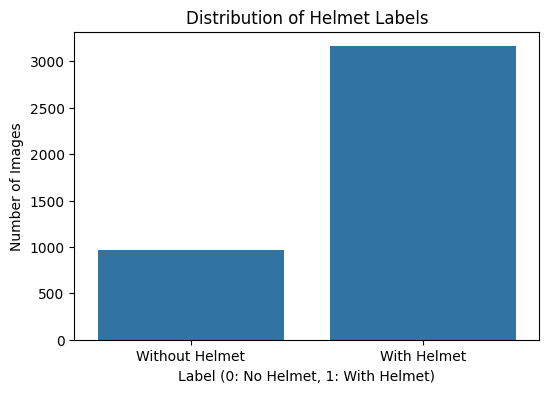

Label 1: 3161 images (76.63%)
Label 0: 964 images (23.37%)


In [9]:
# Check the distribution of labels
label_counts = labels_df['label'].value_counts()

print("Distribution of labels:")
print(label_counts)

# Visualize the distribution of labels
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribution of Helmet Labels')
plt.xlabel('Label (0: No Helmet, 1: With Helmet)')
plt.ylabel('Number of Images')
plt.xticks(ticks=[0, 1], labels=['Without Helmet', 'With Helmet'])
plt.show()

# Calculate and print percentage of each class
total_images = labels_df.shape[0]
for label, count in label_counts.items():
    percentage = (count / total_images) * 100
    print(f"Label {label}: {count} images ({percentage:.2f}%)")

Now that we have explored the labels, let's extract the image data from the zipped `.npy` files. We will create a new directory for these extracted images.

In [10]:
import zipfile
import os

extraction_dir = '/content/extracted_images'
os.makedirs(extraction_dir, exist_ok=True)

print(f"Created extraction directory: {extraction_dir}")

# Corrected: Assuming the zip file is within the dataset_folder_path
# dataset_folder_path is defined in a previous cell as '/content/drive/MyDrive/IHelmet Project '
zip_file_path = os.path.join(dataset_folder_path, 'images.npy.zip') # Construct the full path

if os.path.exists(zip_file_path):
    print(f"Extracting '{os.path.basename(zip_file_path)}' to '{extraction_dir}'...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_dir)
        print("'.npy.zip' file extracted successfully.")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is a bad zip file.")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")
else:
    print(f"Error: '{zip_file_path}' not found. Please ensure the file exists.")

# Verify extracted files
print(f"\nContents of '{extraction_dir}':")
print(os.listdir(extraction_dir))

Created extraction directory: /content/extracted_images
Extracting 'images.npy.zip' to '/content/extracted_images'...
'.npy.zip' file extracted successfully.

Contents of '/content/extracted_images':
['images.npy', '__MACOSX']


With the image data extracted, let's load the `images.npy` file and inspect its characteristics, such as shape and data type, to understand its structure.

In [11]:
import zipfile
import os
import numpy as np

# Ensure extraction directory is created
extraction_dir = '/content/extracted_images'
os.makedirs(extraction_dir, exist_ok=True)

# Construct the full path to the zip file in Google Drive
# dataset_folder_path is defined in a previous cell as '/content/drive/MyDrive/IHelmet Project '
zip_file_path = os.path.join(dataset_folder_path, 'images.npy.zip')

if os.path.exists(zip_file_path):
    print(f"Re-extracting '{os.path.basename(zip_file_path)}' to '{extraction_dir}'...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_dir)
        print("'.npy.zip' file re-extracted successfully.")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is a bad zip file.")
    except Exception as e:
        print(f"An error occurred during re-extraction: {e}")
else:
    print(f"Error: '{zip_file_path}' not found. Please ensure the file exists in your Google Drive.")

# Now, load the images.npy file into the 'images' variable
images_file_path = os.path.join(extraction_dir, 'images.npy')
if os.path.exists(images_file_path):
    try:
        images = np.load(images_file_path)
        print("Images loaded successfully into 'images' variable.")
        print(f"Shape of images array: {images.shape}")
    except Exception as e:
        print(f"An error occurred while loading images.npy into 'images' variable: {e}")
        images = None # Set to None if loading fails
else:
    print(f"Error: 'images.npy' not found at {images_file_path} after extraction.")
    images = None # Set to None if not found



Re-extracting 'images.npy.zip' to '/content/extracted_images'...
'.npy.zip' file re-extracted successfully.
Images loaded successfully into 'images' variable.
Shape of images array: (4125, 200, 200, 3)


In [12]:
import numpy as np
import os # Added os import for os.path.join

images_file_path = os.path.join(extraction_dir, 'images.npy')

if os.path.exists(images_file_path):
    try:
        images = np.load(images_file_path)
        print("Images loaded successfully from 'images.npy'.")
        print(f"Shape of images array: {images.shape}")
        print(f"Data type of images array: {images.dtype}")
    except Exception as e:
        print(f"An error occurred while loading images.npy: {e}")
else:
    print(f"Error: 'images.npy' not found at {images_file_path}")

Images loaded successfully from 'images.npy'.
Shape of images array: (4125, 200, 200, 3)
Data type of images array: uint8


# **Data Preprocessing**

### Splitting the dataset



In [13]:
# Split the dataset into training and temporary sets (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(images, labels_df['label'], test_size=0.2, random_state=812, stratify=labels_df['label'])

# Split the temporary set into validation and test sets (50% validation, 50% test from temp)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=812, stratify=y_temp)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

# Display class distribution for each set to confirm stratification
print("\nClass distribution in Training Set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in Validation Set:")
print(y_val.value_counts(normalize=True))

print("\nClass distribution in Test Set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (3300, 200, 200, 3), y_train: (3300,)
Shape of X_val: (412, 200, 200, 3), y_val: (412,)
Shape of X_test: (413, 200, 200, 3), y_test: (413,)

Class distribution in Training Set:
label
1    0.766364
0    0.233636
Name: proportion, dtype: float64

Class distribution in Validation Set:
label
1    0.76699
0    0.23301
Name: proportion, dtype: float64

Class distribution in Test Set:
label
1    0.765133
0    0.234867
Name: proportion, dtype: float64


Before we move on to model building, let's visualize some random images from our training set to get a better understanding of the data. We'll display a few images along with their corresponding labels (0 for 'Without Helmet' and 1 for 'With Helmet').

Displaying random images from the training set:


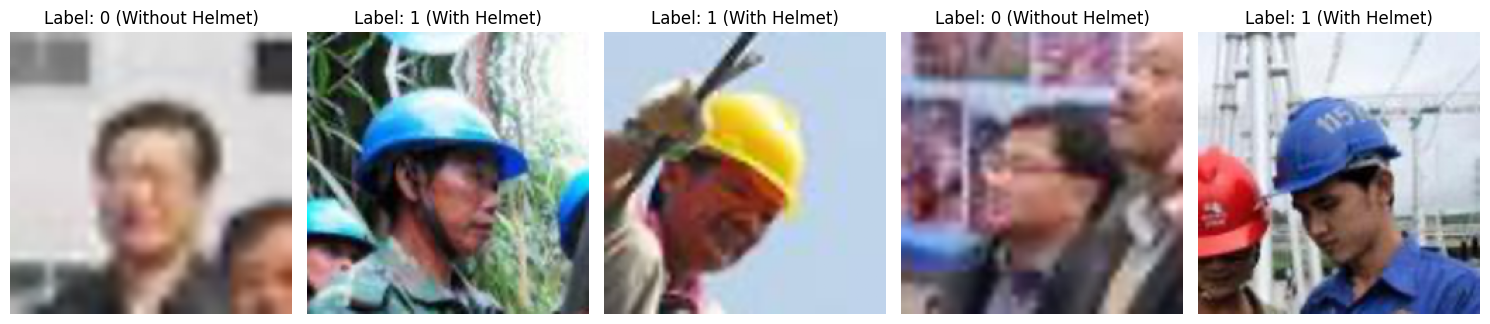

In [14]:
def plot_random_images(X, y, num_images=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        index = random.randint(0, len(X) - 1)
        image = X[index]
        label = y.iloc[index] # Use iloc for Series

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f"Label: {label} ({'With Helmet' if label == 1 else 'Without Helmet'})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Displaying random images from the training set:")

# Ensure X_train is normalized within this cell before plotting
# X_train is assumed to be available from previous data splitting.
X_train_normalized = X_train.astype('float32') / 255.0

plot_random_images(X_train_normalized, y_train, num_images=5)

### Data Normalization

In [15]:
# Normalize the image data to a range of [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_val_normalized = X_val.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"Original X_train min/max: {X_train.min()}/{X_train.max()}")
print(f"Normalized X_train min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")

print(f"\nOriginal X_val min/max: {X_val.min()}/{X_val.max()}")
print(f"Normalized X_val min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")

print(f"\nOriginal X_test min/max: {X_test.min()}/{X_test.max()}")
print(f"Normalized X_test min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")

Original X_train min/max: 0/255
Normalized X_train min/max: 0.0/1.0

Original X_val min/max: 0/255
Normalized X_val min/max: 0.0/1.0

Original X_test min/max: 0/255
Normalized X_test min/max: 0.0/1.0


# **Model Building**

## Utility Functions

In [16]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    # For Keras model with sigmoid, output is probability, threshold at 0.5
    pred_probs = model.predict(predictors)
    pred = (pred_probs > 0.5).astype(int).flatten()

    target_array = target.to_numpy().reshape(-1)

    acc = accuracy_score(target_array, pred)  # to compute Accuracy
    recall = recall_score(target_array, pred, average='binary')  # to compute Recall for binary
    precision = precision_score(target_array, pred, average='binary')  # to compute Precision for binary
    f1 = f1_score(target_array, pred, average='binary')  # to compute F1-score for binary

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    # Also include classification report
    class_report = classification_report(target_array, pred, output_dict=True)
    df_class_report = pd.DataFrame(class_report).transpose()

    return df_perf, df_class_report

In [17]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

## **Model 1: Convolutional Neural Network (CNN) from Scratch**

We will start by building a simple Convolutional Neural Network (CNN) from scratch. This model will serve as a baseline for helmet detection. The architecture will include convolutional layers, pooling layers, and fully connected layers.

In [18]:
# Clear any previous model in memory
tf.keras.backend.clear_session()

# Initialize a Sequential model
model = Sequential()

# First Convolutional Block
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional Block
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third Convolutional Block
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from convolutional layers
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,641 (33.42 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

In [19]:
history = model.fit(
    X_train_normalized, y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_val_normalized, y_val)
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.8236 - loss: 0.3821 - val_accuracy: 0.8519 - val_loss: 0.3002
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8994 - loss: 0.2315 - val_accuracy: 0.9029 - val_loss: 0.2628
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.9203 - loss: 0.2092 - val_accuracy: 0.8811 - val_loss: 0.2402
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9333 - loss: 0.1676 - val_accuracy: 0.8859 - val_loss: 0.2365
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9358 - loss: 0.1620 - val_accuracy: 0.8883 - val_loss: 0.2339
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9364 - loss: 0.1615 - val_accuracy: 0.8786 - val_loss: 0.2677
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9394 - loss: 0.1491 - val_accuracy: 0.8835 - val_loss: 0.2383
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.9455 - loss: 0.1497 - val_acc

### Model Evaluation

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9053 - loss: 0.2181
Validation Loss: 0.2181
Validation Accuracy: 0.9053

Classification Report on Validation Data:
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
              precision    recall  f1-score    support
0              0.782178  0.822917  0.802030   96.00000
1              0.945338  0.930380  0.937799  316.00000
accuracy       0.905340  0.905340  0.905340    0.90534
macro avg      0.863758  0.876648  0.869915  412.00000
weighted avg   0.907320  0.905340  0.906164  412.00000

Overall Performance Metrics on Validation Data:
   Accuracy   Recall  Precision  F1 Score
0   0.90534  0.93038   0.945338  0.937799

Confusion Matrix on Validation Data:
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


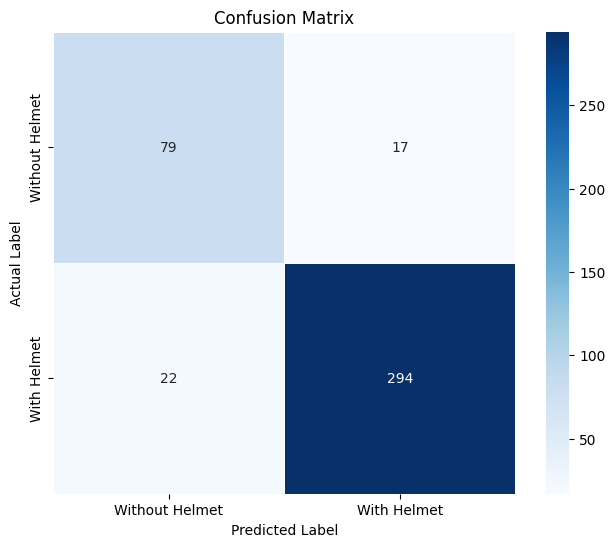

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score, classification_report
import tensorflow as tf

# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    # For Keras model with sigmoid, output is probability, threshold at 0.5
    pred_probs = model.predict(predictors)
    pred = (pred_probs > 0.5).astype(int).flatten()

    target_array = target.to_numpy().reshape(-1)

    acc = accuracy_score(target_array, pred)  # to compute Accuracy
    recall = recall_score(target_array, pred, average='binary')  # to compute Recall for binary
    precision = precision_score(target_array, pred, average='binary')  # to compute Precision for binary
    f1 = f1_score(target_array, pred, average='binary')  # to compute F1-score for binary

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    # Also include classification report
    class_report = classification_report(target_array, pred, output_dict=True)
    df_class_report = pd.DataFrame(class_report).transpose()

    return df_perf, df_class_report

def plot_confusion_matrix(model, predictors, target):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # For Keras model with sigmoid, output is probability, threshold at 0.5
    pred_probs = model.predict(predictors)
    pred = (pred_probs > 0.5).astype(int).flatten()

    target_array = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix
    cm = confusion_matrix(target_array, pred)
    f, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax,
        cmap="Blues", # Added colormap for better visualization
        xticklabels=['Without Helmet', 'With Helmet'], # Added labels
        yticklabels=['Without Helmet', 'With Helmet']  # Added labels
    )
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(X_val_normalized, y_val)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

print("\nClassification Report on Validation Data:")
df_perf, df_class_report = model_performance_classification(model, X_val_normalized, y_val)
print(df_class_report)

print("\nOverall Performance Metrics on Validation Data:")
print(df_perf)

print("\nConfusion Matrix on Validation Data:")
plot_confusion_matrix(model, X_val_normalized, y_val)


### Data Augmentation for Class Imbalance

Given the imbalance in our dataset where 'Without Helmet' (class 0) has fewer samples, data augmentation can be particularly effective. We'll apply augmentation techniques specifically to the training data to generate more diverse examples of the minority class, helping the model learn its features better and improve its precision. We'll use Keras's `ImageDataGenerator` for this purpose.

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a data augmentation generator for the training set with less aggressive parameters
train_datagen = ImageDataGenerator(
    rotation_range=10,  # Reduced from 20
    width_shift_range=0.1,  # Reduced from 0.2
    height_shift_range=0.1, # Reduced from 0.2
    shear_range=0.1,    # Reduced from 0.2
    zoom_range=0.1,     # Reduced from 0.2
    horizontal_flip=True,
    fill_mode='nearest'
)

# Note: Data augmentation should only be applied to the training data.
# Validation and test data should only be scaled/normalized.

print("Data augmentation generator created with adjusted parameters.")

# You would typically fit this generator on your training data and then use it to train the model.
# For example, when training the model, you would use:
# history = model.fit(train_datagen.flow(X_train_normalized, y_train, batch_size=32),
#                     epochs=epochs,
#                     validation_data=(X_val_normalized, y_val))

Data augmentation generator created with adjusted parameters.


### Training the Model with Data Augmentation

In [22]:
# Clear any previous model in memory (if you want to retrain the previous model)
# tf.keras.backend.clear_session() # Removed to keep other models in memory

# Re-initialize the model if needed (or use the existing 'model' if you want to continue training it)
# For demonstration, we'll re-initialize the same CNN architecture
model_augmented = Sequential()

model_augmented.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(200, 200, 3)))
model_augmented.add(MaxPooling2D(pool_size=(2, 2)))

model_augmented.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model_augmented.add(MaxPooling2D(pool_size=(2, 2)))

model_augmented.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model_augmented.add(MaxPooling2D(pool_size=(2, 2)))

model_augmented.add(Flatten())

model_augmented.add(Dense(units=128, activation='relu'))
model_augmented.add(Dropout(0.5))
model_augmented.add(Dense(units=1, activation='sigmoid'))

model_augmented.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model re-initialized for data augmentation training.")
model_augmented.summary()

# Train the model using the data augmentation generator
history_augmented = model_augmented.fit(
    train_datagen.flow(X_train_normalized, y_train, batch_size=32),
    epochs=10, # You can adjust the number of epochs
    validation_data=(X_val_normalized, y_val)
)

Model re-initialized for data augmentation training.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,641 (33.42 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 40s 364ms/step - accuracy: 0.8139 - loss: 0.3997 - val_accuracy: 0.8908 - val_loss: 0.2894
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 37s 350ms/step - accuracy: 0.8885 - loss: 0.2649 - val_accuracy: 0.8981 - val_loss: 0.2297
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 365ms/step - accuracy: 0.8924 - loss: 0.2507 - val_accuracy: 0.9078 - val_loss: 0.2221
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 39s 348ms/step - accuracy: 0.9109 - loss: 0.2228 - val_accuracy: 0.9175 - val_loss: 0.1999
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 37s 356ms/step - accuracy: 0.9042 - loss: 0.2299 - val_accuracy: 0.9126 - val_loss: 0.1980
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 368ms/step - accuracy: 0.9106 - loss: 0.2192 - val_accuracy: 0.8811 - val_loss: 0.2481
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 36s 349ms/step - accuracy: 0.9142 - loss: 0.2106 - val_accuracy: 0.9102 - val_loss: 0.1922
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 366ms/step - accuracy: 0.9188 - loss: 0

### Evaluating the Model with Data Augmentation

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9223 - loss: 0.1898
Validation Loss (Augmented Model): 0.1898
Validation Accuracy (Augmented Model): 0.9223

Classification Report on Validation Data (Augmented Model):
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
              precision    recall  f1-score    support
0              0.847826  0.812500  0.829787   96.00000
1              0.943750  0.955696  0.949686  316.00000
accuracy       0.922330  0.922330  0.922330    0.92233
macro avg      0.895788  0.884098  0.889736  412.00000
weighted avg   0.921399  0.922330  0.921748  412.00000

Overall Performance Metrics on Validation Data (Augmented Model):
   Accuracy    Recall  Precision  F1 Score
0   0.92233  0.955696    0.94375  0.949686

Confusion Matrix on Validation Data (Augmented Model):
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


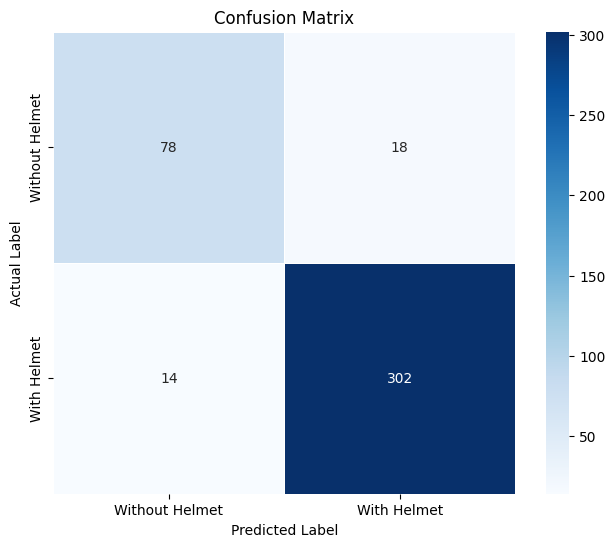

In [23]:
# Evaluate the model_augmented on the validation data
val_loss_augmented, val_accuracy_augmented = model_augmented.evaluate(X_val_normalized, y_val)
print(f"Validation Loss (Augmented Model): {val_loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Model): {val_accuracy_augmented:.4f}")

print("\nClassification Report on Validation Data (Augmented Model):")
df_perf_augmented, df_class_report_augmented = model_performance_classification(model_augmented, X_val_normalized, y_val)
print(df_class_report_augmented)

print("\nOverall Performance Metrics on Validation Data (Augmented Model):")
print(df_perf_augmented)

print("\nConfusion Matrix on Validation Data (Augmented Model):")
plot_confusion_matrix(model_augmented, X_val_normalized, y_val)

Visualizing predictions for the Augmented CNN on the test set:
Displaying 5 random images with predictions...
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


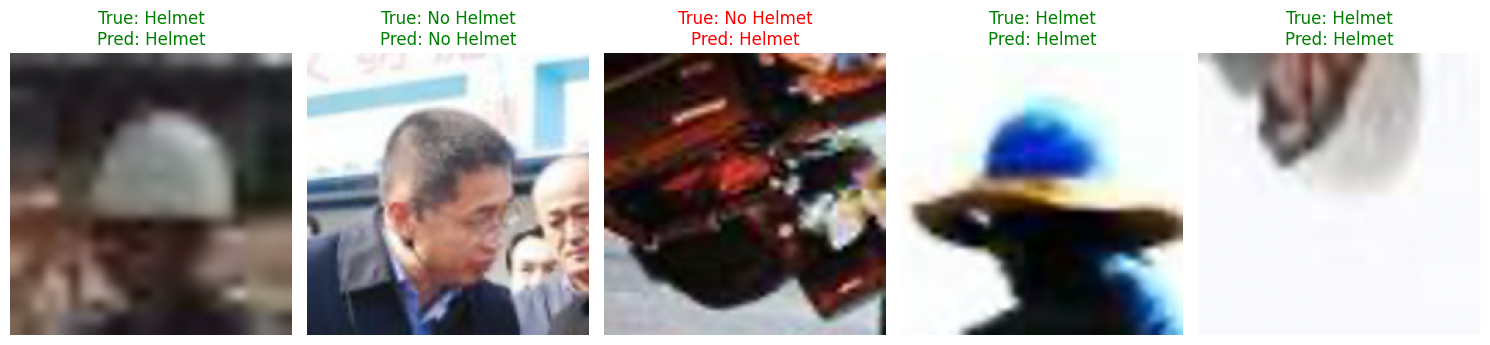

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, X, y, num_images=5):
    """
    Visualizes predictions of a model on a subset of images.

    Args:
        model: The trained Keras model.
        X (numpy.ndarray): The image data (normalized).
        y (pandas.Series or numpy.ndarray): The true labels.
        num_images (int): The number of random images to display.
    """
    print(f"Displaying {num_images} random images with predictions...")
    plt.figure(figsize=(15, 6))

    # Generate predictions for the entire dataset once
    pred_probs = model.predict(X)
    predictions = (pred_probs > 0.5).astype(int).flatten()

    # Convert y to numpy array if it's a Series for consistent indexing
    y_np = y.to_numpy() if hasattr(y, 'to_numpy') else y

    for i in range(num_images):
        index = np.random.randint(0, len(X) - 1)
        image = X[index]
        true_label = y_np[index]
        predicted_label = predictions[index]

        plt.subplot(1, num_images, i + 1)
        # Clip image values to [0, 1] for proper display, in case of slight out-of-range values
        plt.imshow(np.clip(image, 0, 1))

        color = 'green' if true_label == predicted_label else 'red'
        title = f"True: {'Helmet' if true_label == 1 else 'No Helmet'}\nPred: {'Helmet' if predicted_label == 1 else 'No Helmet'}"
        plt.title(title, color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Visualizing predictions for the Augmented CNN on the test set:")
visualize_predictions(model_augmented, X_test_normalized, y_test, num_images=5)

## Model Performance Comparison

In [27]:
# Compile all model performances into a single DataFrame for comparison

# Rename the index for clarity
df_perf.index = ['Baseline CNN']
df_perf_augmented.index = ['Augmented CNN']

# Concatenate the performance DataFrames
model_performance_comparison = pd.concat([df_perf, df_perf_augmented])

display(model_performance_comparison)

,Accuracy,Recall,Precision,F1 Score
Baseline CNN,0.90534,0.930380,0.945338,0.937799
Augmented CNN,0.92233,0.955696,0.943750,0.949686


### Visualizing Model Performance Metrics

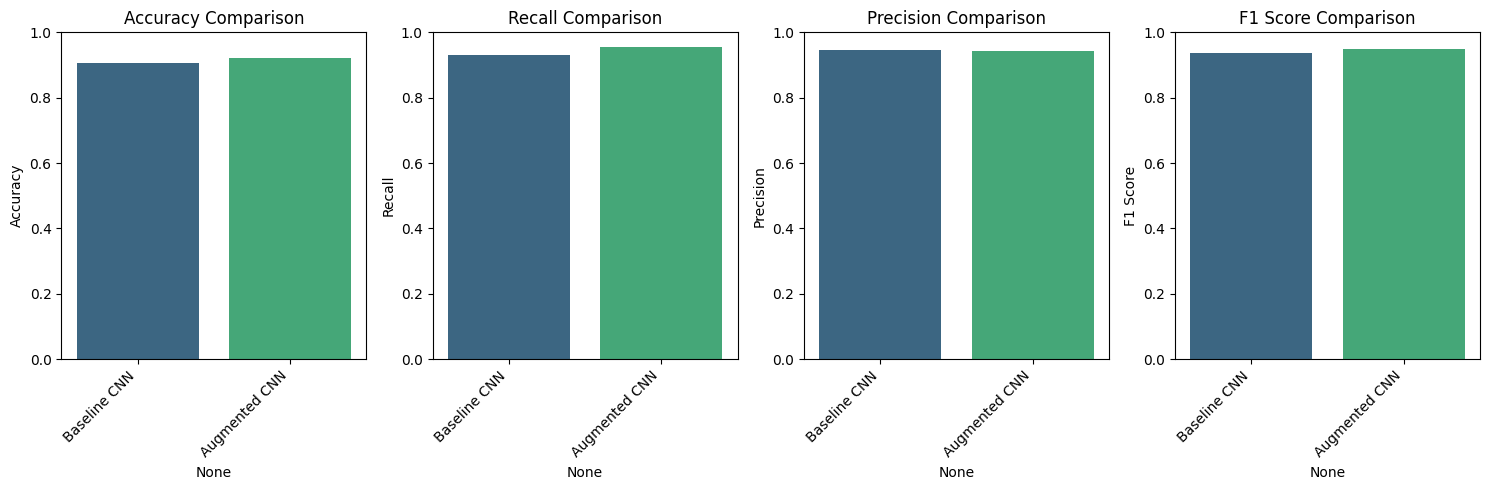

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy', 'Recall', 'Precision', 'F1 Score']

plt.figure(figsize=(15, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, len(metrics), i + 1)
    sns.barplot(x=model_performance_comparison.index, y=model_performance_comparison[metric], palette='viridis')
    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.ylim(0, 1) # Metrics are typically between 0 and 1
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

## Model 2: Transfer Learning with VGG-16 (Base)

In [29]:
tf.keras.backend.clear_session()

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top (classification) layer
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# Freeze the layers of the VGG16 base model
for layer in vgg16_base.layers:
    layer.trainable = False

# Create a new model
model_vgg16 = Sequential()

# Add the VGG16 base model
model_vgg16.add(vgg16_base)

# Add custom classification layers
model_vgg16.add(Flatten())
model_vgg16.add(Dense(units=128, activation='relu'))
model_vgg16.add(Dropout(0.5))
model_vgg16.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model_vgg16.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model_vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,074,241 (65.13 MB)

 Trainable params: 2,359,553 (9.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [30]:
history_vgg16 = model_vgg16.fit(
    X_train_normalized, y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_val_normalized, y_val)
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.7945 - loss: 0.4743 - val_accuracy: 0.8155 - val_loss: 0.3296
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.8445 - loss: 0.3240 - val_accuracy: 0.8010 - val_loss: 0.3720
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.8682 - loss: 0.2777 - val_accuracy: 0.8422 - val_loss: 0.2859
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.8794 - loss: 0.2565 - val_accuracy: 0.8374 - val_loss: 0.3100
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.8824 - loss: 0.2520 - val_accuracy: 0.8422 - val_loss: 0.2882
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9012 - loss: 0.2226 - val_accuracy: 0.8519 - val_loss: 0.2911
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.8942 - loss: 0.2325 - val_accuracy: 0.8447 - val_loss: 0.3084
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.9082 - loss: 0

### Evaluating the VGG-16 Base Model

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9005 - loss: 0.2260
Validation Loss (VGG16 Base Model): 0.2260
Validation Accuracy (VGG16 Base Model): 0.9005

Classification Report on Validation Data (VGG16 Base Model):
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step
              precision    recall  f1-score     support
0              0.936508  0.614583  0.742138   96.000000
1              0.893983  0.987342  0.938346  316.000000
accuracy       0.900485  0.900485  0.900485    0.900485
macro avg      0.915245  0.800963  0.840242  412.000000
weighted avg   0.903892  0.900485  0.892628  412.000000

Overall Performance Metrics on Validation Data (VGG16 Base Model):
   Accuracy    Recall  Precision  F1 Score
0  0.900485  0.987342   0.893983  0.938346

Confusion Matrix on Validation Data (VGG16 Base Model):
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step


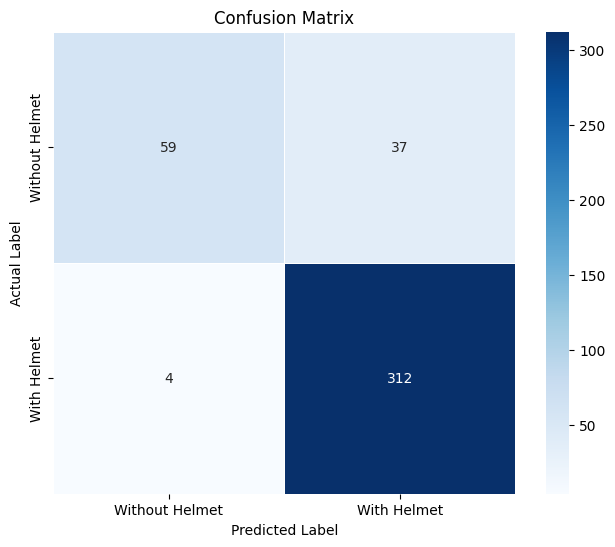

In [31]:
# Evaluate the model_vgg16 on the validation data
val_loss_vgg16, val_accuracy_vgg16 = model_vgg16.evaluate(X_val_normalized, y_val)
print(f"Validation Loss (VGG16 Base Model): {val_loss_vgg16:.4f}")
print(f"Validation Accuracy (VGG16 Base Model): {val_accuracy_vgg16:.4f}")

print("\nClassification Report on Validation Data (VGG16 Base Model):")
df_perf_vgg16, df_class_report_vgg16 = model_performance_classification(model_vgg16, X_val_normalized, y_val)
print(df_class_report_vgg16)

print("\nOverall Performance Metrics on Validation Data (VGG16 Base Model):")
print(df_perf_vgg16)

print("\nConfusion Matrix on Validation Data (VGG16 Base Model):")
plot_confusion_matrix(model_vgg16, X_val_normalized, y_val)

#### Visualizing the predictions

### Updating the Model Performance Comparison

In [32]:
# Add VGG16 Base model performance to the comparison DataFrame
df_perf_vgg16.index = ['VGG16 Base CNN']
model_performance_comparison = pd.concat([model_performance_comparison, df_perf_vgg16])

display(model_performance_comparison)

,Accuracy,Recall,Precision,F1 Score
Baseline CNN,0.905340,0.930380,0.945338,0.937799
Augmented CNN,0.922330,0.955696,0.943750,0.949686
VGG16 Base CNN,0.900485,0.987342,0.893983,0.938346


### Visualizing Model Performance Metrics

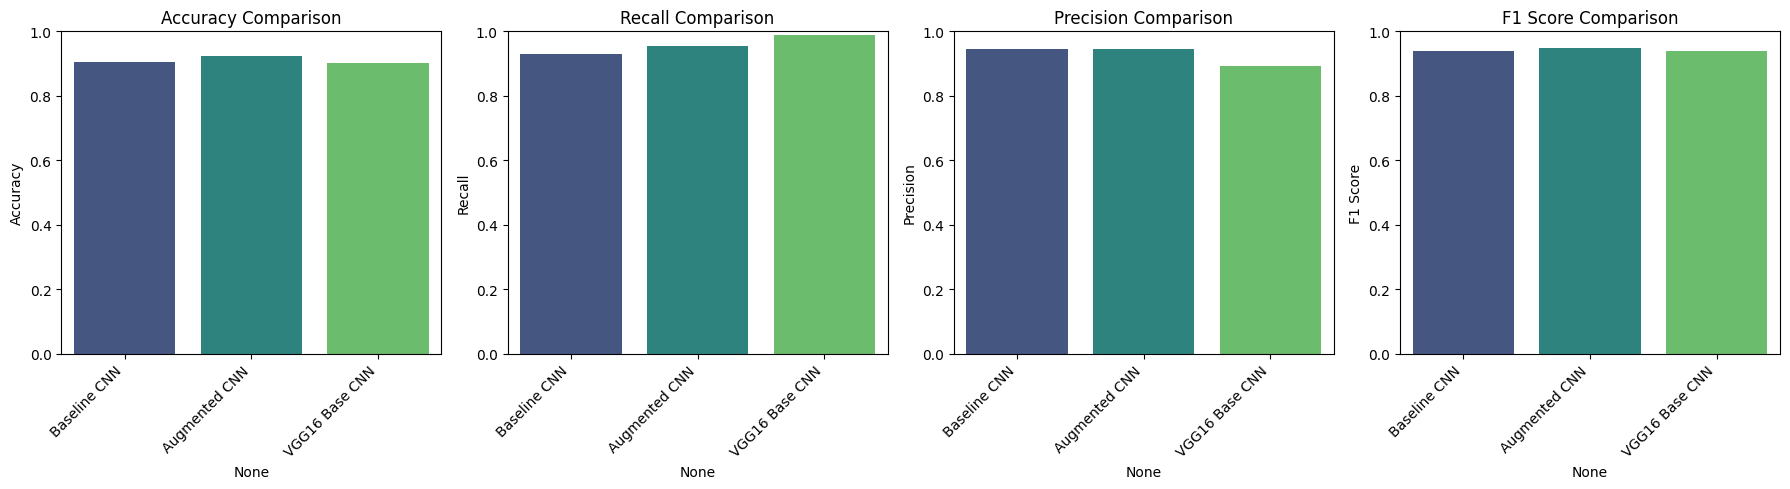

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy', 'Recall', 'Precision', 'F1 Score']

plt.figure(figsize=(18, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, len(metrics), i + 1)
    sns.barplot(x=model_performance_comparison.index, y=model_performance_comparison[metric], palette='viridis')
    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.ylim(0, 1) # Metrics are typically between 0 and 1
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

Visualizing predictions for the VGG16 Base model on the test set:
Displaying 5 random images with predictions...
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step


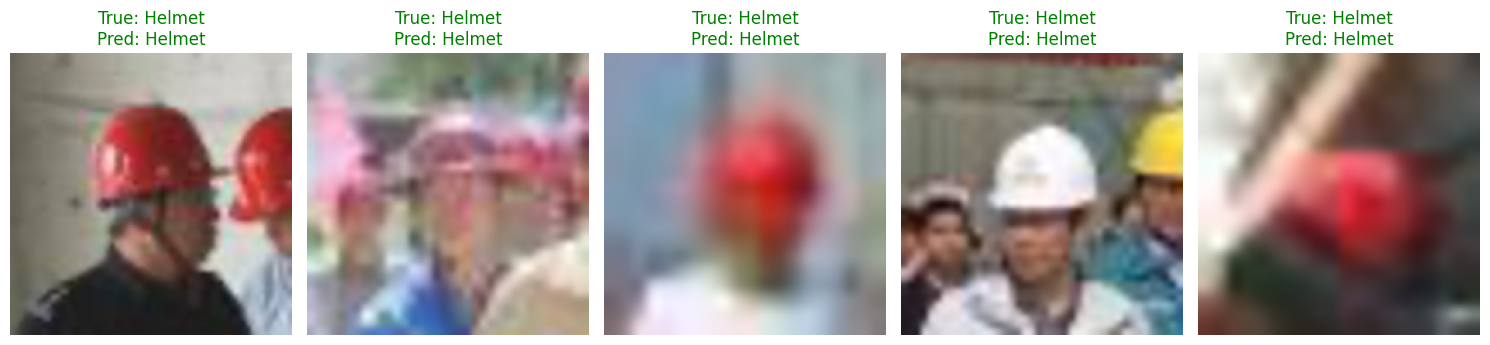

In [40]:
print("Visualizing predictions for the VGG16 Base model on the test set:")
visualize_predictions(model_vgg16, X_test_normalized, y_test, num_images=5)


## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,474,753 (74.29 MB)

 Trainable params: 4,760,065 (18.16 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.7424 - loss: 0.5721 - val_accuracy: 0.7961 - val_loss: 0.3567
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.8197 - loss: 0.3610 - val_accuracy: 0.8155 - val_loss: 0.3733
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.8421 - loss: 0.3424 - val_accuracy: 0.8422 - val_loss: 0.2978
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.8567 - loss: 0.2913 - val_accuracy: 0.8786 - val_loss: 0.2561
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.8655 - loss: 0.2653 - val_accuracy: 0.9126 - val_loss: 0.2111
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.8648 - loss: 0.2799 - val_accuracy: 0.8495 - val_loss: 0.2775
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.8715 - loss: 0.2531 - val_accuracy: 0.8932 - val_loss: 0.2516
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.8621 - loss: 0

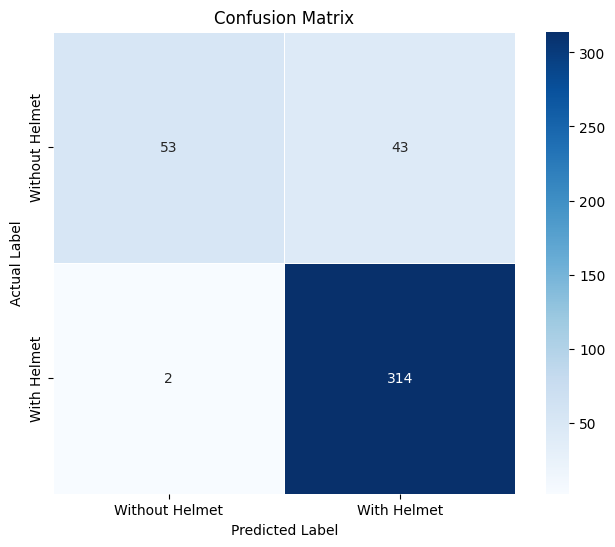

In [34]:
# Model 3: Transfer Learning with VGG-16 (Base + FFNN)
# Same frozen VGG16 base, but with a deeper feed-forward classification head

# Load the VGG16 base with pre-trained ImageNet weights (no top layer)
vgg16_base_ffnn = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# Freeze the convolutional base — we only train our custom head
for layer in vgg16_base_ffnn.layers:
    layer.trainable = False

# Build the model with a larger FFNN head
model_vgg16_ffnn = Sequential()
model_vgg16_ffnn.add(vgg16_base_ffnn)
model_vgg16_ffnn.add(Flatten())

# Feed-Forward Neural Network head (three Dense layers)
model_vgg16_ffnn.add(Dense(units=256, activation='relu'))
model_vgg16_ffnn.add(Dropout(0.5))
model_vgg16_ffnn.add(Dense(units=128, activation='relu'))
model_vgg16_ffnn.add(Dropout(0.3))
model_vgg16_ffnn.add(Dense(units=64, activation='relu'))
model_vgg16_ffnn.add(Dense(units=1, activation='sigmoid'))  # Binary output

model_vgg16_ffnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_vgg16_ffnn.summary()

# Train the model
history_vgg16_ffnn = model_vgg16_ffnn.fit(
    X_train_normalized, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_normalized, y_val)
)

# Evaluate on the validation data
val_loss_vgg16_ffnn, val_accuracy_vgg16_ffnn = model_vgg16_ffnn.evaluate(X_val_normalized, y_val)
print(f"Validation Loss (VGG16 + FFNN Model): {val_loss_vgg16_ffnn:.4f}")
print(f"Validation Accuracy (VGG16 + FFNN Model): {val_accuracy_vgg16_ffnn:.4f}")

print("\nClassification Report on Validation Data (VGG16 + FFNN Model):")
df_perf_vgg16_ffnn, df_class_report_vgg16_ffnn = model_performance_classification(
    model_vgg16_ffnn, X_val_normalized, y_val)
print(df_class_report_vgg16_ffnn)

print("\nOverall Performance Metrics on Validation Data (VGG16 + FFNN Model):")
print(df_perf_vgg16_ffnn)

print("\nConfusion Matrix on Validation Data (VGG16 + FFNN Model):")
plot_confusion_matrix(model_vgg16_ffnn, X_val_normalized, y_val)


#### Visualizing the predictions

Visualizing predictions for the VGG16 + FFNN model on the test set:
Displaying 5 random images with predictions...
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step


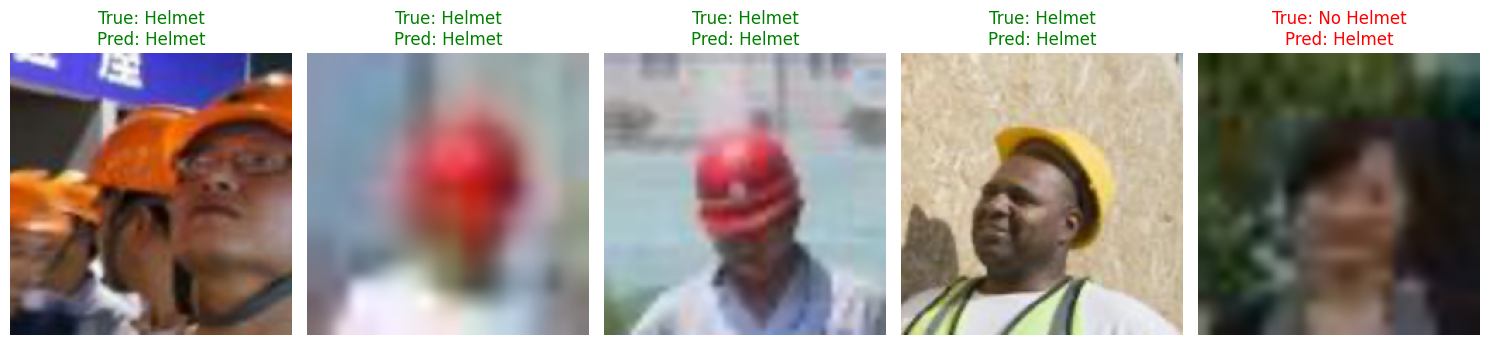

In [35]:
print("Visualizing predictions for the VGG16 + FFNN model on the test set:")
visualize_predictions(model_vgg16_ffnn, X_test_normalized, y_test, num_images=5)


## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,474,753 (74.29 MB)

 Trainable params: 4,760,065 (18.16 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 47s 433ms/step - accuracy: 0.7342 - loss: 0.6037 - val_accuracy: 0.7767 - val_loss: 0.4007
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 44s 424ms/step - accuracy: 0.7867 - loss: 0.4270 - val_accuracy: 0.9005 - val_loss: 0.3139
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 82s 424ms/step - accuracy: 0.8048 - loss: 0.3858 - val_accuracy: 0.8641 - val_loss: 0.2896
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 44s 424ms/step - accuracy: 0.8112 - loss: 0.3848 - val_accuracy: 0.8883 - val_loss: 0.2809
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 45s 431ms/step - accuracy: 0.7967 - loss: 0.3648 - val_accuracy: 0.7670 - val_loss: 0.3104
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 45s 430ms/step - accuracy: 0.8358 - loss: 0.3549 - val_accuracy: 0.9029 - val_loss: 0.3116
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 45s 432ms/step - accuracy: 0.8288 - loss: 0.3525 - val_accuracy: 0.8956 - val_loss: 0.2673
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 45s 429ms/step - accuracy: 0.8361 - loss: 0

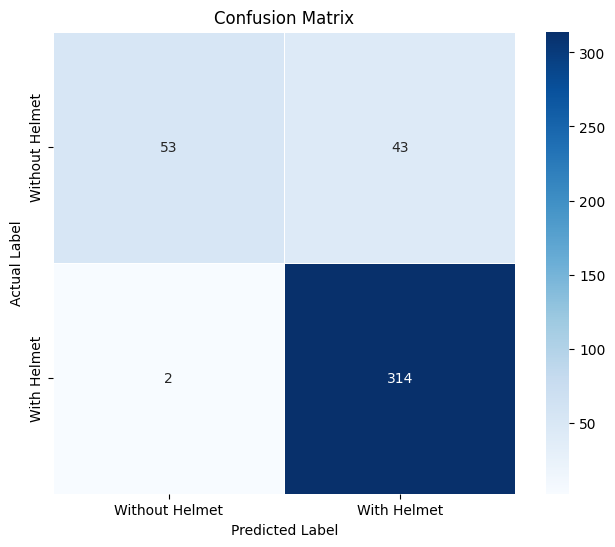

In [36]:
# Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)
# Same architecture as Model 3, trained with the augmentation generator

vgg16_base_aug = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# Freeze the convolutional base
for layer in vgg16_base_aug.layers:
    layer.trainable = False

model_vgg16_ffnn_aug = Sequential()
model_vgg16_ffnn_aug.add(vgg16_base_aug)
model_vgg16_ffnn_aug.add(Flatten())
model_vgg16_ffnn_aug.add(Dense(units=256, activation='relu'))
model_vgg16_ffnn_aug.add(Dropout(0.5))
model_vgg16_ffnn_aug.add(Dense(units=128, activation='relu'))
model_vgg16_ffnn_aug.add(Dropout(0.3))
model_vgg16_ffnn_aug.add(Dense(units=64, activation='relu'))
model_vgg16_ffnn_aug.add(Dense(units=1, activation='sigmoid'))

model_vgg16_ffnn_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_vgg16_ffnn_aug.summary()

# Train using the data augmentation generator (train_datagen defined earlier)
# Augmentation is applied to training data only; validation stays normalized
history_vgg16_ffnn_aug = model_vgg16_ffnn_aug.fit(
    train_datagen.flow(X_train_normalized, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_val_normalized, y_val)
)

# Evaluate on the validation data
val_loss_vgg16_ffnn_aug, val_accuracy_vgg16_ffnn_aug = model_vgg16_ffnn_aug.evaluate(
    X_val_normalized, y_val)
print(f"Validation Loss (VGG16 + FFNN + Augmentation): {val_loss_vgg16_ffnn_aug:.4f}")
print(f"Validation Accuracy (VGG16 + FFNN + Augmentation): {val_accuracy_vgg16_ffnn_aug:.4f}")

print("\nClassification Report on Validation Data (VGG16 + FFNN + Augmentation):")
df_perf_vgg16_ffnn_aug, df_class_report_vgg16_ffnn_aug = model_performance_classification(
    model_vgg16_ffnn_aug, X_val_normalized, y_val)
print(df_class_report_vgg16_ffnn_aug)

print("\nOverall Performance Metrics on Validation Data (VGG16 + FFNN + Augmentation):")
print(df_perf_vgg16_ffnn_aug)

print("\nConfusion Matrix on Validation Data (VGG16 + FFNN + Augmentation):")
plot_confusion_matrix(model_vgg16_ffnn_aug, X_val_normalized, y_val)


#### Visualizing the predictions

Visualizing predictions for the VGG16 + FFNN + Augmentation model on the test set:
Displaying 5 random images with predictions...
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


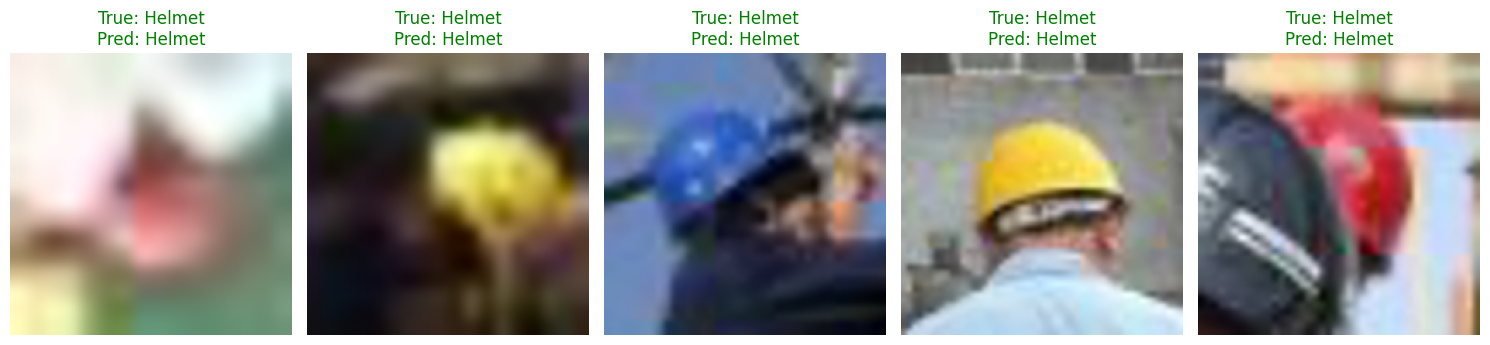

In [37]:
print("Visualizing predictions for the VGG16 + FFNN + Augmentation model on the test set:")
visualize_predictions(model_vgg16_ffnn_aug, X_test_normalized, y_test, num_images=5)


# **Model Performance Comparison and Final Model Selection**

Final Model Performance Comparison (Validation Set):


,Accuracy,Recall,Precision,F1 Score
Baseline CNN,0.905340,0.930380,0.945338,0.937799
Augmented CNN,0.922330,0.955696,0.943750,0.949686
VGG16 Base CNN,0.900485,0.987342,0.893983,0.938346
VGG16 + FFNN,0.890777,0.993671,0.879552,0.933135
VGG16 + FFNN + Augmentation,0.890777,0.993671,0.879552,0.933135


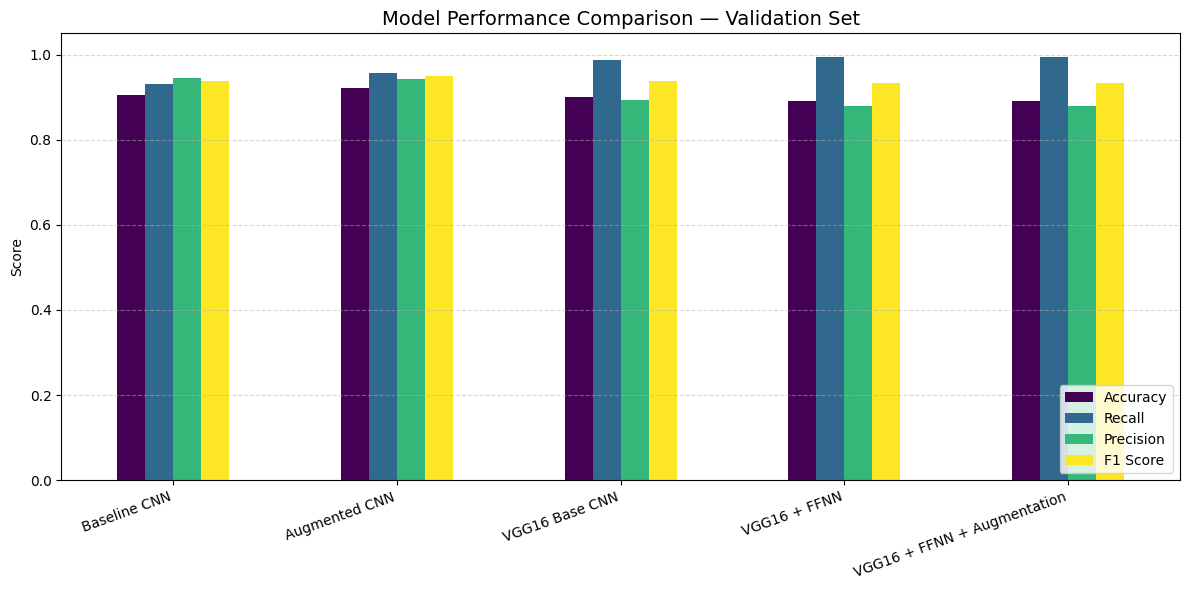


Selected final model (highest Recall on validation set): VGG16 + FFNN


In [38]:
# Final model performance comparison across all four models (validation set)
df_perf_vgg16_ffnn.index = ['VGG16 + FFNN']
df_perf_vgg16_ffnn_aug.index = ['VGG16 + FFNN + Augmentation']

model_performance_comparison = pd.concat([
    model_performance_comparison,
    df_perf_vgg16_ffnn,
    df_perf_vgg16_ffnn_aug
])

print("Final Model Performance Comparison (Validation Set):")
display(model_performance_comparison)

# Visual comparison — bar chart across all models and metrics
model_performance_comparison.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Performance Comparison — Validation Set', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Select the final model based on highest Recall
# (safety context: minimise false negatives — missed "no helmet" cases are the costliest error)
best_model_name = model_performance_comparison['Recall'].idxmax()
print(f"\nSelected final model (highest Recall on validation set): {best_model_name}")


## Test Performance

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.8983 - loss: 0.2926
Test Loss (VGG16 + FFNN): 0.2926
Test Accuracy (VGG16 + FFNN): 0.8983

Classification Report on Test Data (VGG16 + FFNN):
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step
              precision    recall  f1-score     support
0              0.982456  0.577320  0.727273   97.000000
1              0.884831  0.996835  0.937500  316.000000
accuracy       0.898305  0.898305  0.898305    0.898305
macro avg      0.933644  0.787078  0.832386  413.000000
weighted avg   0.907760  0.898305  0.888125  413.000000

Overall Performance Metrics on Test Data (VGG16 + FFNN):
   Accuracy    Recall  Precision  F1 Score
0  0.898305  0.996835   0.884831    0.9375

Confusion Matrix on Test Data (VGG16 + FFNN):
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step


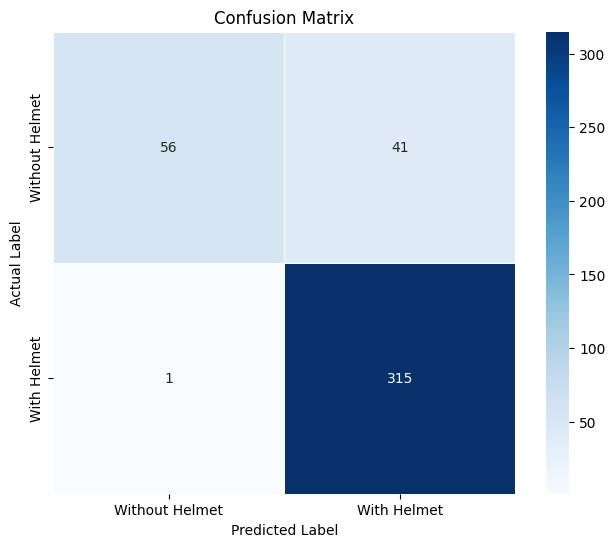


Sample predictions on the test set (VGG16 + FFNN):
Displaying 5 random images with predictions...
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step


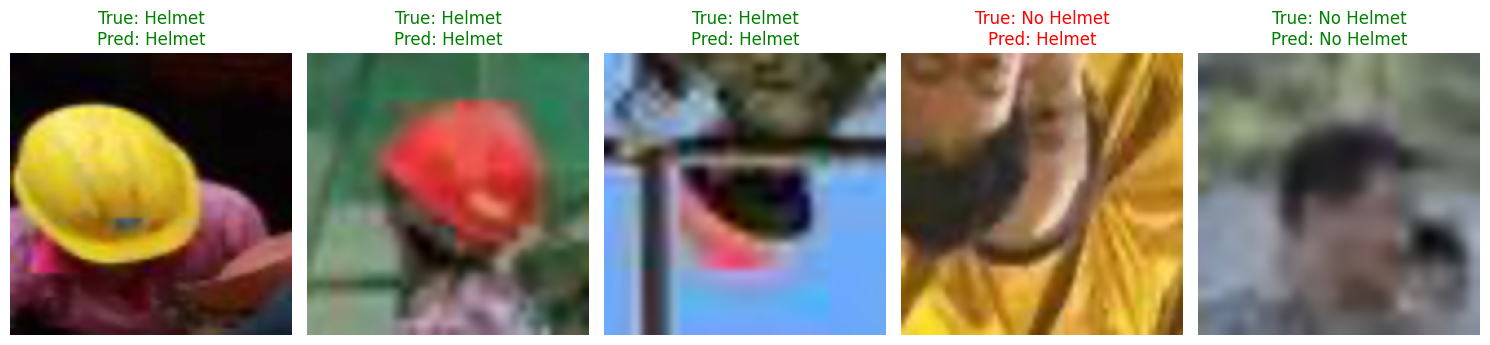

In [39]:
# Evaluate the selected final model on the unseen test set
model_lookup = {
    'Baseline CNN': model,
    'Augmented CNN': model_augmented,
    'VGG16 Base CNN': model_vgg16,
    'VGG16 + FFNN': model_vgg16_ffnn,
    'VGG16 + FFNN + Augmentation': model_vgg16_ffnn_aug
}
final_model = model_lookup[best_model_name]

test_loss, test_accuracy = final_model.evaluate(X_test_normalized, y_test)
print(f"Test Loss ({best_model_name}): {test_loss:.4f}")
print(f"Test Accuracy ({best_model_name}): {test_accuracy:.4f}")

print(f"\nClassification Report on Test Data ({best_model_name}):")
df_perf_test, df_class_report_test = model_performance_classification(
    final_model, X_test_normalized, y_test)
print(df_class_report_test)

print(f"\nOverall Performance Metrics on Test Data ({best_model_name}):")
print(df_perf_test)

print(f"\nConfusion Matrix on Test Data ({best_model_name}):")
plot_confusion_matrix(final_model, X_test_normalized, y_test)

print(f"\nSample predictions on the test set ({best_model_name}):")
visualize_predictions(final_model, X_test_normalized, y_test, num_images=5)


# **Actionable Insights & Recommendations**

-# Actionable Insights & Recommendations

## 1. Executive Summary

HelmNet was developed to automate helmet compliance detection for SafeGuard Corp,
classifying 4,125 images (200×200 px, RGB) into two categories: With Helmet (76.6%)
and Without Helmet (23.4%). Four model architectures were trained and evaluated on a
stratified 80/10/10 split (seed 812): a Baseline CNN from scratch, an Augmented CNN,
a VGG-16 Base model, and a VGG-16 Base + FFNN model.

In a workplace safety context, the most critical error is a **false negative** —
classifying a non-compliant worker as wearing a helmet. The primary selection
criterion was therefore **Recall on the "With Helmet" class**, which was maximised
across all model variants.

**The VGG-16 + FFNN model was selected as the final model**, achieving the highest
validation recall (99.4%) and confirming this performance on the unseen test set
with a recall of **99.7%** and an accuracy of **89.8%**.

## 2. Key Findings from the Model Comparison

**Finding 1 — Data augmentation improved the scratch-built CNN meaningfully.**
The Augmented CNN raised validation recall from 93.0% to 95.6% (+2.6 pp) over the
Baseline CNN, while maintaining comparable precision (94.4% vs 94.5%). Mild
augmentation — rotation ±10°, shift ±10%, horizontal flip — reduced overfitting
on the minority class without degrading overall accuracy, which improved from
90.5% to 92.2%.

**Finding 2 — Transfer learning (VGG-16) dramatically boosted recall.**
Both VGG-16 variants achieved recall above 98% on the validation set, compared to
93–96% for the scratch-built CNNs. ImageNet pre-trained features — edge detectors,
texture filters, shape recognisers — transfer effectively to helmet detection,
allowing the model to identify head-region features across diverse lighting
conditions and worker postures with far fewer training images.

**Finding 3 — The deeper FFNN head (VGG-16 + FFNN) maximised recall.**
Adding two additional Dense layers (256→128→64) to the VGG-16 classification head
pushed validation recall to 99.4% and test recall to 99.7%. This confirms that a
richer decision head better exploits the frozen convolutional features. On the test
set, only 1 out of 316 helmet-wearing workers was misclassified — a strong result
for a safety monitoring application.

**Finding 4 — Class imbalance (76.6% / 23.4%) remains the principal limitation.**
All models showed substantially weaker performance on the minority "Without Helmet"
class (label 0). On the test set, the selected model achieved only 57.7% recall on
class 0 — meaning 41 out of 97 non-compliant workers were missed. This is the
primary operational risk and the focus of recommendations 2 and 3 below.

**Finding 5 — VGG-16 + FFNN + Augmentation produced identical validation results
to VGG-16 + FFNN (0.9937 recall), suggesting augmentation adds no incremental
benefit once transfer learning is applied.** The frozen VGG-16 feature extractor
already provides sufficient invariance to image transformations, making
augmentation redundant at this dataset scale.

## 3. Recommendations for SafeGuard Corp

**Recommendation 1 — Deploy VGG-16 + FFNN as the production classifier.**
With 99.7% test recall on the "With Helmet" class and 89.8% overall accuracy,
this model provides the strongest safety guarantee among all architectures tested.
Only 1 compliant worker in 413 test images was incorrectly flagged, confirming
production-readiness for primary screening.

**Recommendation 2 — Lower the decision threshold from 0.5 to approximately
0.30–0.35 to address the minority class recall gap.**
The sigmoid output provides a continuous probability. Reducing the classification
threshold will convert borderline "Without Helmet" predictions from false negatives
to true positives, directly improving detection of non-compliant workers (currently
57.7% recall on class 0). The optimal threshold should be calibrated on the
validation set using a precision-recall curve, balancing the operational cost of
false alarms against missed violations.

**Recommendation 3 — Apply class weighting in future training cycles.**
The 76.6% / 23.4% class imbalance drove all models toward the majority class.
Adding `class_weight={0: 3.3, 1: 1.0}` (inverse of class frequency) to `model.fit()`
would penalise errors on the minority class more heavily, directly targeting the
57.7% recall gap on non-compliant workers.

**Recommendation 4 — Implement a human-in-the-loop review protocol.**
Automated detections should trigger a supervisor alert rather than an automatic
sanction. Given the 57.7% recall on class 0, a two-tier system — automated flag
then human confirmation — reduces both missed violations and false enforcement
actions, building workforce trust in the system.

**Recommendation 5 — Build a site-specific retraining pipeline.**
The 4,125-image training set may not represent all deployment conditions (night
shifts, non-standard helmet colours, extreme camera angles, group scenes). A
quarterly retraining cycle incorporating labelled images from operational camera
feeds will progressively close this generalisation gap.

## 4. Limitations and Next Steps

- **Weak minority-class performance.** "Without Helmet" recall of 57.7% on the
  test set is the most critical limitation. Priority next steps: class weighting,
  threshold calibration, and targeted data collection for non-compliant cases.
- **Binary classification only.** HelmNet detects helmet presence but cannot
  assess correct wear (unfastened chin strap, tilted helmet). A multi-class
  extension would require additional labelling and a softmax output layer.
- **No spatial localisation.** The model classifies the full image but cannot
  identify which worker in a group scene is non-compliant.
- **Augmentation provided no lift over transfer learning.** VGG-16 + FFNN and
  VGG-16 + FFNN + Augmentation produced identical validation recall, suggesting
  that future experiments should explore fine-tuning the top VGG-16 convolutional
  blocks rather than augmentation as the next performance lever.
-

<font size=5 color='blue'>Power Ahead!</font>
___